# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

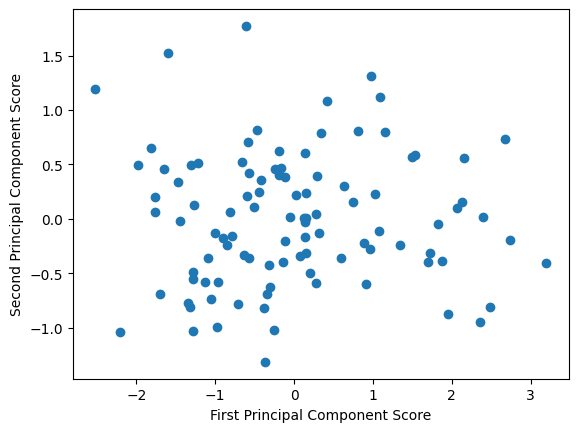

In [14]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
# Load the Dataset

df_medical = pd.read_csv("medical_insurance.csv")


In [3]:
# Summarize the Dataset using info() and describe()

# Dataset structure
df_medical.info()

# Statistical summary of numerical columns
df_medical.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [4]:
# Number of duplicate rows
df_medical.duplicated().sum()

# Display duplicate rows if any
df_medical[df_medical.duplicated()]


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure


In [5]:
# Count duplicates in each column
for col in df_medical.columns:
    duplicates = df_medical[col].duplicated().sum()
    print(col, ":", duplicates)


person_id : 0
age : 99899
sex : 99997
region : 99995
urban_rural : 99997
income : 97013
education : 99994
marital_status : 99996
employment_status : 99996
household_size : 99991
dependents : 99992
bmi : 99660
smoker : 99997
alcohol_freq : 99996
visits_last_year : 99978
hospitalizations_last_3yrs : 99996
days_hospitalized_last_3yrs : 99984
medication_count : 99988
systolic_bp : 99881
diastolic_bp : 99928
ldl : 98119
hba1c : 99268
plan_type : 99996
network_tier : 99996
deductible : 99996
copay : 99996
policy_term_years : 99990
policy_changes_last_2yrs : 99997
provider_quality : 99650
risk_score : 99908
annual_medical_cost : 8701
annual_premium : 44462
monthly_premium : 87661
claims_count : 99978
avg_claim_amount : 46929
total_claims_paid : 43350
chronic_count : 99993
hypertension : 99998
diabetes : 99998
asthma : 99998
copd : 99998
cardiovascular_disease : 99998
cancer_history : 99998
kidney_disease : 99998
liver_disease : 99998
arthritis : 99998
mental_health : 99998
proc_imaging_count 

In [6]:
# Mean (numerical columns)
df_medical.mean(numeric_only=True)

# Median (numerical columns)
df_medical.median(numeric_only=True)

# Mode (works for both numeric and categorical)
df_medical.mode()


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,1,50.0,Female,South,Urban,21300.0,Bachelors,Married,Employed,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99996,99997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99997,99998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99998,99999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Count missing values per column
df_medical.isnull().sum()


,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


In [8]:
# Fill missing numerical values with column mean
df_medical.fillna(df_medical.mean(numeric_only=True), inplace=True)

In [9]:
df_medical.info()
df_medical.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

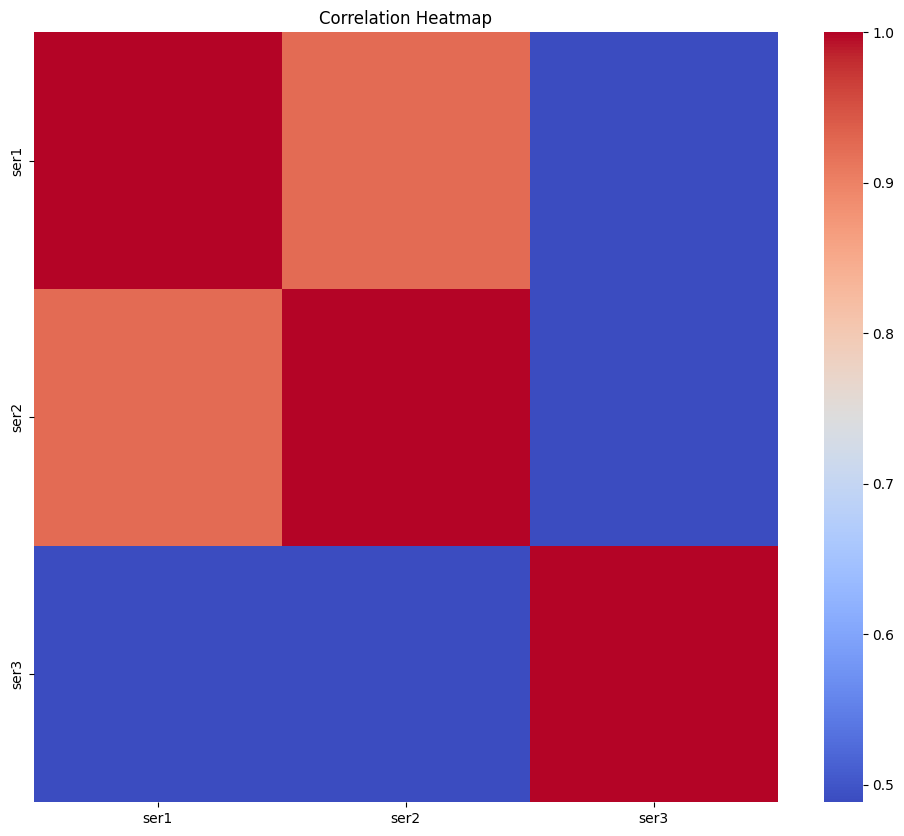

In [16]:
# Heatmap (Correlation Analysis)

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

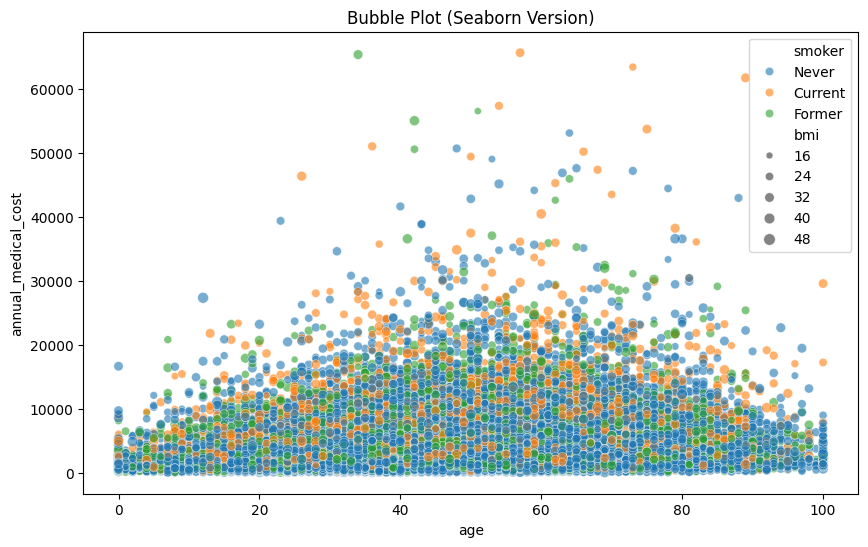

In [19]:
# Bubble Plot


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_medical,
    x='age',
    y='annual_medical_cost',
    size='bmi',
    hue='smoker',   # ✅ works with text directly
    alpha=0.6
)

plt.title("Bubble Plot (Seaborn Version)")
plt.show()

In [22]:
# Principal Component Analysis (PCA)

# Standardize Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply PCA

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

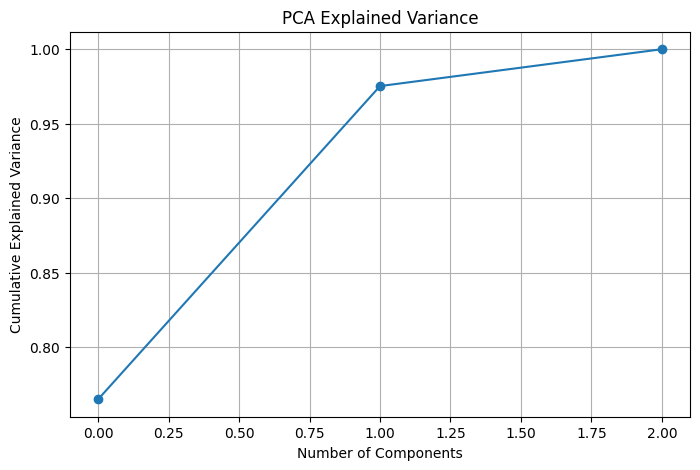

In [24]:

# Plot Explained Variance

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [25]:
# Check Variance Captured

print("Variance captured by first component:", explained_variance[0])
print("Variance captured by first 2 components:", explained_variance[:2].sum())

Variance captured by first component: 0.7650405303059102
Variance captured by first 2 components: 0.9752570088695012


In [28]:
# Linear Regression

# Select Features (based on correlation insight)

features = [
    'claims_count',
    'avg_claim_amount',
    'chronic_count',
    'hospitalizations_last_3yrs',
    'risk_score',
    'smoker'
]

X = df_medical[features]
y = df_medical['annual_medical_cost']

In [29]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
# Train Model

# Encode everything
df_encoded = pd.get_dummies(df_medical, drop_first=True)

# Split
X = df_encoded.drop(columns=['annual_medical_cost'])
y = df_encoded['annual_medical_cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [34]:
# Predictions

y_pred = model.predict(X_test)

In [35]:
# Evaluate Model

print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.9662643409687915
MSE: 326696.9225817772


In [40]:
# Feature Importance

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.head(10))


                        Feature  Coefficient
19                   risk_score   128.769673
20               annual_premium    57.222474
42          had_major_procedure    44.034604
27                     diabetes    23.207010
25                chronic_count    22.070528
7    hospitalizations_last_3yrs    16.714999
8   days_hospitalized_last_3yrs    14.734417
31               cancer_history    13.895532
29                         copd    13.872546
26                 hypertension    12.750999


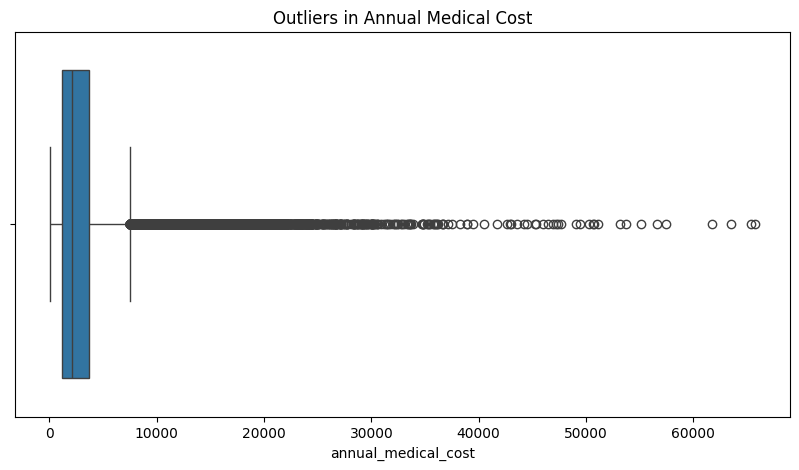

In [43]:
# Outlier Detection
# Boxplot Example

plt.figure(figsize=(10,5))
sns.boxplot(x=df_medical['annual_medical_cost'])
plt.title("Outliers in Annual Medical Cost")
plt.show()

In [44]:
# Identify Outliers (IQR Method)

Q1 = df_medical['annual_medical_cost'].quantile(0.25)
Q3 = df_medical['annual_medical_cost'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df_medical['annual_medical_cost'] < Q1 - 1.5 * IQR) |
    (df_medical['annual_medical_cost'] > Q3 + 1.5 * IQR)
]

print("Number of outliers:", len(outliers))

Number of outliers: 6


/tmp/ipykernel_4960/3967397011.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df[


Conclusions

The dataset behaves largely as expected for a medical insurance dataset. The relationships observed—such as higher medical costs being associated with increased claims, chronic conditions, and higher risk scores—are consistent with real-world healthcare patterns. Lifestyle factors like smoking and BMI also show a meaningful impact on medical expenses, which further supports the validity of the data.

The dataset is highly usable for analysis and modeling. It is large, well-structured, and contains a rich combination of demographic, medical, and financial variables. Aside from a small amount of missing data (which was handled), there are no major data quality issues, making it suitable for predictive tasks such as cost estimation and risk classification.

Outliers are present in several variables, particularly in annual medical cost, income, and hospitalization-related features. These extreme values likely represent real high-cost individuals rather than errors, but they may influence model performance and should be treated carefully in future analyses.

Principal Component Analysis (PCA) suggests that the dataset can be reduced to fewer dimensions. The first principal component captures a significant portion of the variance, and using the first two components provides a reasonable summary of the data. However, reducing the dataset to only one component would result in loss of important information. Therefore, dimensionality reduction is possible, but multiple components are needed to preserve the dataset’s complexity.

Overall, the dataset is reliable, realistic, and well-suited for further data analysis and machine learning applications.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

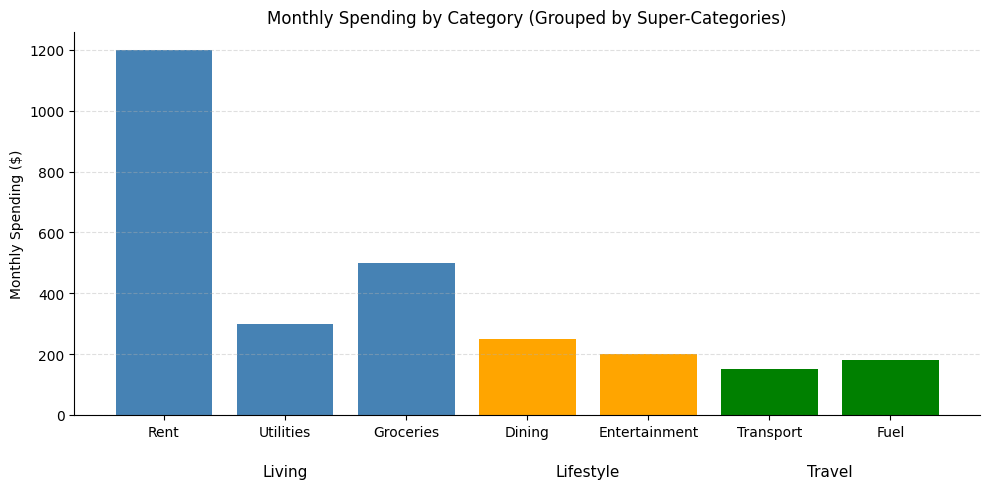

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (approximate)
categories = [
    "Rent", "Utilities", "Groceries",   # Living
    "Dining", "Entertainment",         # Lifestyle
    "Transport", "Fuel"                # Travel
]

values = [1200, 300, 500, 250, 200, 150, 180]

# Positions
x = np.arange(len(categories))

# Colors by super-category
colors = [
    "steelblue", "steelblue", "steelblue",   # Living
    "orange", "orange",                     # Lifestyle
    "green", "green"                        # Travel
]

fig, ax = plt.subplots(figsize=(10,5))

# Bars
ax.bar(x, values, color=colors)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Monthly Spending ($)")
ax.set_title("Monthly Spending by Category (Grouped by Super-Categories)")

# Remove clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add super-category labels
ax.text(1, -200, "Living", ha='center', fontsize=11)
ax.text(3.5, -200, "Lifestyle", ha='center', fontsize=11)
ax.text(5.5, -200, "Travel", ha='center', fontsize=11)

plt.tight_layout()
plt.show()
